In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import conductivity as cd
from matplotlib.ticker import MaxNLocator

# Mean spherical approximation (MSA) model constants

In [2]:
# temperature in K
temp = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
diff_coeff_Ca_Na = [Diff_Ca, Diff_Na, Diff_Cl]
diff_coeff_La_Na = [Diff_La, Diff_Na, Diff_Cl] 

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
diameter_Ca_Na = [sigma_Ca, sigma_Na, sigma_Cl]
diameter_La_Na = [sigma_La, sigma_Na, sigma_Cl]

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_Ca_Na = [lambda_0_Ca_mol, lambda_0_Na_mol, lambda_0_Cl_mol]
lambda_0_La_Na = [lambda_0_La_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

# Shedlovsky model constants

In [3]:
# solvent viscosity in poise
eta_shed = 8.9*10**(-3)

# limiting equivalent conductivity of salts in cm^2.Siemen.equiv^(-1)
lambda_0_NaCl = 126.45 
lambda_0_CaCl2 = 135.85
lambda_0_LaCl3 = 145.9

# limiting equivalent conductivity of ions in cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10
lambda_0_Ca = 59.5
lambda_0_La = 69.7
lambda_0_Cl = 76.35

# distance from an ion within which no other ion can penetrate in cm
a_NaCl = 4*10**(-8)
a_CaCl2 = 4.31*10**(-8)
a_LaCl3 = 4.9*10**(-8)
a_NaCl_CaCl2 = (a_NaCl + a_CaCl2)/2
a_NaCl_LaCl3 = (a_NaCl + a_LaCl3)/2

# Determine the cation ratio to discriminate between the Shedlovsky and MSA models in extreme binary salt mixtures 

In [4]:
# define the concentration of the trace cation
NaCl_conc = [1, 2, 3, 4, 5]

# define the desired ionic strength of the binary salt mixture
# we want experiments at ionic strengths below 1000 mM
ionic_strength_limit = 1000

# define the cation ratios to evaluate
cation_ratio = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

In [5]:
def ionic_strength(salt_1_conc, salt_2_conc, valency):
    """ 
    Calculates the ionic strength of the salt solution

    Arguments:
        salt_1_conc: pandas.Series or list or numpy.ndarray
            Concentration of the highest-valence salt in mM
        salt_2_conc: pandas.Series or list or numpy.ndarray
            Concentration of the lowest-valence salt in mM
        valency: list
            Valency of ions in decreasing order

    Returns:
        ionic_strength: list
            Ionic strength of the salt solution
    """
    # get the number of datapoints
    ndata = len(salt_1_conc)
    
    # calculate the species concentration
    cation_1_conc = salt_1_conc
    cation_2_conc = salt_2_conc
    anion_conc = [valency[0] * salt_1_conc[i] + valency[1] * salt_2_conc[i] 
                  for i in range(ndata)]
    n_species = len(valency)
    
    # calculate the ionic stength of the solution
    ionic_strength = []
    for i in range(ndata):
        ion_conc = [cation_1_conc[i], cation_2_conc[i], anion_conc[i]]
        ionic_strength.append(0.5 * sum(ion_conc[j] * valency[j] ** 2 for j in range(n_species)))

    return ionic_strength

In [6]:
def extreme_binary_salt(
    NaCl_conc,
    dominant_cation,
    valency,
    cation_ratio,
    ionic_strength_threshold,
):
    """
    Calculates the prediction difference between the Shedlovsky and MSA models 
    based on the desired concentration of NaCl and the cation ratio and total 
    ionic strength of the binary salt solution

    Arguments:
        NaCl_conc: pandas.Series or list or numpy.ndarray
            Concentration of NaCl in mM
        dominant_cation: str
            Name of the dominant cation
        valency: list
            Valency of ions in decreasing order
        cation_ratio: list
            Ratio of the concentration of the cations
        ionic_strength_threshold: int or float
            Value of the ionic strength to not exceed
    """
    NaCl_conc = np.asarray(NaCl_conc, dtype=float)
    ndata = len(NaCl_conc)

    # store all heat-map rows:
    # [Na+ concentration, cation ratio, percent difference]
    data_res = []

    for ratio in cation_ratio:
        # get the concentration of the dominant cation for this ratio
        cation_2_conc_plot = ratio * NaCl_conc

        # calculate the ionic strength
        ionic_str = ionic_strength(
            cation_2_conc_plot,
            NaCl_conc,
            valency,
        )

        if np.any(np.asarray(ionic_str) > ionic_strength_threshold):
            residuals_percent = np.full(ndata, np.nan)

        else:
            # convert mM to M for the Shedlovsky model
            conc_NaCl_shed = NaCl_conc * 1e-3
            conc_cation_2_shed = cation_2_conc_plot * 1e-3

            if dominant_cation == "calcium":
                # calculate the individual salt conductivity using the Shedlovsky 
                # model
                shed_cond_NaCl = cd.shedlovsky(
                    conc_NaCl_shed,
                    temp,
                    epsilon,
                    eta_shed,
                    lambda_0_NaCl,
                    a_NaCl_CaCl2,
                    z_Na,
                    z_Cl,
                    lambda_0_Na,
                    lambda_0_Cl,
                )

                shed_cond_cation_2 = cd.shedlovsky(
                    conc_cation_2_shed,
                    temp,
                    epsilon,
                    eta_shed,
                    lambda_0_CaCl2,
                    a_NaCl_CaCl2,
                    z_Ca,
                    z_Cl,
                    lambda_0_Ca,
                    lambda_0_Cl,
                )

                # calculate the bulk conductivity using the MSA model
                msa_cond = cd.msa(
                    valency,
                    diameter_Ca_Na,
                    diff_coeff_Ca_Na,
                    temp,
                    eta_msa,
                    epsilon,
                    lambda_0_Ca_Na,
                    cation_2_conc_plot,
                    NaCl_conc,
                )

            elif dominant_cation == "lanthanum":
                shed_cond_NaCl = cd.shedlovsky(
                    conc_NaCl_shed,
                    temp,
                    epsilon,
                    eta_shed,
                    lambda_0_NaCl,
                    a_NaCl_LaCl3,
                    z_Na,
                    z_Cl,
                    lambda_0_Na,
                    lambda_0_Cl,
                )

                shed_cond_cation_2 = cd.shedlovsky(
                    conc_cation_2_shed,
                    temp,
                    epsilon,
                    eta_shed,
                    lambda_0_LaCl3,
                    a_NaCl_LaCl3,
                    z_La,
                    z_Cl,
                    lambda_0_La,
                    lambda_0_Cl,
                )

                msa_cond = cd.msa(
                    valency,
                    diameter_La_Na,
                    diff_coeff_La_Na,
                    temp,
                    eta_msa,
                    epsilon,
                    lambda_0_La_Na,
                    cation_2_conc_plot,
                    NaCl_conc,
                )

            else:
                raise ValueError(
                    "dominant_cation must be 'calcium' or 'lanthanum'."
                )

            # calculate the bulk conductivity using the Shedlovsky model
            shed_cond = (
                np.asarray(shed_cond_NaCl)
                + np.asarray(shed_cond_cation_2)
            )
            msa_cond = np.asarray(msa_cond)

            # compute the percent difference between the predictions of the 
            # MSA and Shedlovksy models
            residuals_percent = (
                100 * np.abs(shed_cond - msa_cond) / msa_cond
            )
            print(f"The prediction residual of cation ratio {ratio} is:",
                  residuals_percent)

        # add all points for the current ratio.
        for i in range(ndata):
            data_res.append(
                [
                    NaCl_conc[i],
                    ratio,
                    residuals_percent[i],
                ]
            )

    data_res = np.asarray(data_res, dtype=float)

    # plot the model difference results
    # X and Y axis labels
    x_label = r"Concentration of Na$\mathbf{^{+}}$ (mM)"

    if dominant_cation == "calcium":
        y_label = r"Ca$\mathbf{^{2+}}$:Na$\mathbf{^{+}}$ Molar Ratio"
    else:
        y_label = r"La$\mathbf{^{3+}}$:Na$\mathbf{^{+}}$ Molar Ratio"

    plot_heatmap(
        data_res,
        y_label,
        x_label,
        "Model Prediction Difference (%)",
        dominant_cation,
    )

In [7]:
# Make the heat map plot
def plot_heatmap(data, y_label, x_label, colorbar_label, figure_name):
    """
    Arguments:
        data: numpy.ndarray,
            Matrix containing the concentration of the salts and 
            the model prediction difference
        y_label: str
            Y-axis label for the heat map plot
        x_label: str
            X-axis label for the heat map plot
        colorbar_label: str
            Colorbar label for the heat map plot
        figure_name: str
            Name of figure to save on the GitHub repository
    """
    # set the heatmap x,y ranges
    x_values = np.sort(np.unique(data[:, 0]))
    y_values = np.sort(np.unique(data[:, 1]))

    opt_vals = np.full(
        (len(y_values), len(x_values)),
        np.nan,
    )

    # map each data row to its corresponding grid location.
    for x, y, value in data:
        x_index = np.where(x_values == x)[0][0]
        y_index = np.where(y_values == y)[0][0]
        opt_vals[y_index, x_index] = value

    fig, ax = plt.subplots()

    plt.rcParams.update({"mathtext.default": "regular"})

    cmap = plt.cm.hot_r.copy()
    cmap.set_bad(color="lightgray")

    im = ax.imshow(
        opt_vals,
        cmap=cmap,
        origin="lower",
        aspect="auto",
    )

    ax.set_xticks(range(len(x_values)))
    ax.set_xticklabels([f"{x:g}" for x in x_values])
    ax.set_xlabel(x_label, fontsize=16.5, fontweight="bold")

    ax.set_yticks(range(len(y_values)))
    ax.set_yticklabels([f"{y:g}" for y in y_values])
    ax.set_ylabel(y_label, fontsize=16.5, fontweight="bold")

    ax.tick_params(axis="both", labelsize=16.5)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=10))

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(
        colorbar_label,
        fontsize=16.5,
        fontweight="bold",
    )
    cbar.ax.tick_params(labelsize=16.5)

    plt.tight_layout()
    plt.savefig(f"Binary_salts/{figure_name}_extreme_binary_ratio_heat.png")
    plt.show()

Relaxation correction: [-0.09469778 -0.03179159 -0.09170225]
Hydrodynamic correction: [-0.31077664 -0.18414446 -0.11213416]
Relative ionic strength: [0.64516129 0.01612903 0.33870968]
Transport number: [0.41857147 0.01762545 0.56380308]
Ionic mobility: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 296479979298.8141
Alpha: [np.float64(0.0), np.float64(314377828380.1818), np.float64(363363042458.17706)]
zeta matrix: [[ 1.39968364 -0.40234685 -0.5177654 ]
 [ 0.83099658  6.83145266 -3.0621612 ]
 [ 0.54554598  0.44106768  1.13203701]]
The prediction residual of cation ratio 10 is: [0.77160168 0.97181835 1.09330546 1.17600614 1.23545639]
Relaxation correction: [-0.10939843 -0.03673214 -0.10762608]
Hydrodynamic correction: [-0.40016069 -0.23696146 -0.14147736]
Relative ionic strength: [0.6557377  0.00819672 0.33606557]
Transport number: [0.42809075 0.00901315 0.5628961 ]
Ionic mobility: [1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 294639520204.7261
Alpha

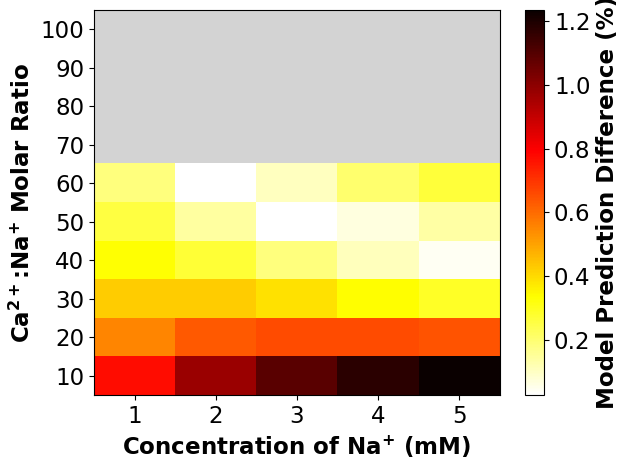

In [8]:
extreme_binary_salt(NaCl_conc, "calcium", [z_Ca, z_Na, z_Cl], cation_ratio, ionic_strength_limit,)

Relaxation correction: [-0.14379796 -0.01252572 -0.13956337]
Hydrodynamic correction: [-0.49531449 -0.2346361  -0.14006673]
Relative ionic strength: [0.73770492 0.00819672 0.25409836]
Transport number: [0.46411077 0.01111333 0.5247759 ]
Ionic mobility: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 238958889824.024
Alpha: [np.float64(0.0), np.float64(316514427315.101), np.float64(362591387782.3)]
zeta matrix: [[ 1.39319386 -0.25252261 -0.38717081]
 [ 0.64646702  8.82142861 -3.42731478]
 [ 0.42440305  0.44856793  1.23460284]]
The prediction residual of cation ratio 10 is: [0.30651109 0.16455125 0.03885725 0.26095641 0.48677844]
Relaxation correction: [-0.15660693 -0.01343865 -0.15425991]
Hydrodynamic correction: [-0.61921385 -0.29499461 -0.17225276]
Relative ionic strength: [0.74380165 0.00413223 0.25206612]
Transport number: [0.4707105  0.00563568 0.52365382]
Ionic mobility: [1.50335711e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 237555674169.36157
Alpha: [np

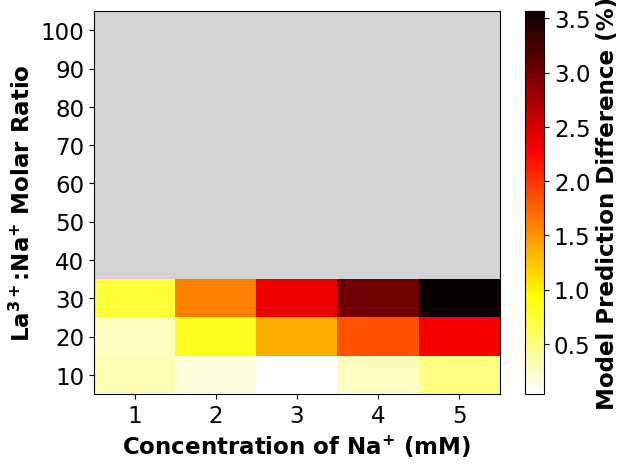

In [9]:
extreme_binary_salt(NaCl_conc, "lanthanum", [z_La, z_Na, z_Cl], cation_ratio, ionic_strength_limit,)